## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `li

---
## <u>Image Transformations & Load Dataset</u>

MNIST images are grayscale, 1 colour channel, unlike CIFAR10/cat-dog's 3 (RGB). `Normalize` needs exactly one mean/std pair per channel, so a single-item tuple `(0.5,)` here, not three values.

MNIST is a common enough benchmark that its real per-pixel statistics are known and reused everywhere rather than the generic `0.5`/`0.5` placeholder: mean `0.1307`, std `0.3081`.

`torchvision.datasets.MNIST` auto-downloads on first run, same as CIFAR10 did, no manual Kaggle step needed.

In [2]:
transformations = transforms.Compose([

    # convert image to tensor and scale pixel values to (0,1)
    transforms.ToTensor(),

    # MNIST is grayscale, so only 1 channel input is needed rather than 3
    # (0.5,) is a 1 item tuple, (0.5) is just a plain number in parentheses: the comma matters
    # 0.1307 and 0.3081 are MNIST's actual known mean/std, not a generic placeholder
    # Normalize maps (0,1) -> roughly (-1,1)
    transforms.Normalize((0.1307,), (0.3081,))  # mean, std
])

train_set = MNIST("../dataset", train=True, download=True, transform=transformations)
test_set = MNIST("../dataset", train=False, download=True, transform=transformations)

print(len(train_set), len(test_set))
print(train_set[0][0].shape)  # (1 colour channel, 28 rows, 28 columns)

60000 10000
torch.Size([1, 28, 28])


---
## <u>Build TrainLoader and TestLoader</u>

In [3]:
# train_loader hands us 4D shaped batches (batch_size, 1, 28, 28): (number of images, 1 colour channel, 28 rows, 28 columns)
# but RNN/LSTM want 3D input (batch_size, sequence_length, input_size)
# that reshape happens inside forward(), not here: batch_size can differ between loaders freely,
# it has no effect on the model's architecture, only on how many images get processed per step

train_set, val_set = torch.utils.data.random_split(
    train_set,
    [0.85, 0.15],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, shuffle=True, batch_size=128)
val_loader = DataLoader(val_set, shuffle=False, batch_size=64)   # carved from training data, used for checkpointing
test_loader = DataLoader(test_set, shuffle=False, batch_size=64)  

---
## <u>Model Architecture</u>

No `nn.Embedding` layer this time, unlike the sentiment build. Words needed a lookup table because a word has no inherent numeric value. A pixel's brightness is already a number, directly usable, nothing to look up.

**Treating an image as a sequence:** an RNN reads one timestep at a time, so a static 28x28 image is reframed as a sequence of its own rows: `sequence_length = 28` (one per row), `input_size = 28` (one row's worth of pixels). The model reads the image top to bottom, one row at a time, same recurrence mechanics as reading a sentence word by word.

**Multiclass, not binary:** output layer is `num_classes = 10` neurons (digits 0-9), paired with `CrossEntropyLoss` and `argmax` at evaluation time, not `BCEWithLogitsLoss` and a sigmoid threshold like the sentiment build.

Shape journey (batch_size=128, hidden_size=128, num_layers=1):
```
(128, 1, 28, 28)         128 images, 1 channel, 28x28 pixels: straight from DataLoader
      |
      | x.squeeze(1): drops the channel dimension, it carries no information for grayscale
      v
(128, 28, 28)             128 images, 28 rows each, 28 pixels per row: this goes into the RNN
      |
      | self.rnn(x, h0), h0 shape (1, 128, 128)
      v
out: (128, 28, 128)        hidden state at every one of the 28 row-timesteps
hn:  (1, 128, 128)          hidden state at only the final row: this is what gets kept
      |
      | hn[-1]
      v
(128, 128)                   last layer's final hidden state, the model's summary of the whole image
      |
      | dropout(0.2), then self.fc: Linear(128 -> 10)
      v
(128, 10)                      10 raw class scores per image
```

In [4]:
class RNN(nn.Module):  # inherit from nn.Module: gives access to PyTorch's model machinery

    def __init__(self, input_size=28, hidden_size=128, num_classes=10, num_layers=1):
        super(RNN, self).__init__()

        # saving these so forward() can use them later, same reason as the sentiment model
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.num_layers = num_layers

        # no embedding layer this time: pixels are already numbers, nothing to look up
        # input_size = 28 because each row of the image is one timestep, 28 pixels wide
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        # 10 output neurons instead of 1: this is multiclass now, one score per digit 0-9
        # dropout still sits right before the final linear layer, same spot as the sentiment build
        self.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):

        # each image arrives as (batch, 1, 28, 28): the 1 is just the grayscale channel, carries no real info
        # squeeze(1) drops that specific dimension so the image becomes (batch, 28, 28), what the rnn wants
        # using squeeze(1) and not a bare squeeze() so it only ever touches that channel dim, nothing else
        # (a bare squeeze() would also collapse batch_size if it ever happened to equal 1)
        x_reshaped = x.squeeze(1)

        # blank starting memory, shape (num_layers, batch_size, hidden_size)
        # x.size(0) grabs the batch size directly off the current batch, so it stays correct
        # even if the last batch of an epoch happens to be smaller than usual
        hidden_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # rnn reads the image 28 rows at a time, row by row, starting from hidden_state_0
        # hidden_state_history holds every row's hidden state: not needed here, only the last one matters
        hidden_state_history, final_hidden_state = self.rnn(x_reshaped, hidden_state_0)

        # final_hidden_state is (num_layers, batch, hidden_size)
        # [-1] grabs the last layer and drops that dimension, leaving (batch, hidden_size)
        # that's the model's summary of the whole image after reading all 28 rows
        x_fc = self.fc(final_hidden_state[-1])

        return x_fc

---
## <u>Compile the Model</u>

In [5]:
model = RNN(input_size=28)

loss_func = nn.CrossEntropyLoss()  # multiclass: applies softmax internally, expects raw logits + integer class labels
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Same skeleton as every prior build: outer epoch loop, `model.train()`/`model.eval()`, the five-step batch sequence, checkpoint on best validation loss. `y_batch` here is already plain integer class labels (0-9) straight from `MNIST`, no `.view(-1,1)` needed: that reshape was specific to binary sentiment, not multiclass.

In [6]:
epochs = 20
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_tensor = model(x_batch)
        batch_loss = loss_func(y_pred_tensor, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred_tensor = model(x_batch)
            batch_loss = loss_func(y_pred_tensor, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch = {epoch + 1}/{epochs} -----------> train loss = {avg_train_loss} -----------> validation loss = {avg_val_loss}")

    if best_val_loss > avg_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_rnn_model.pt")

print("best model at epoch : ", best_epoch)

epoch = 1/20 -----------> train loss = 0.935383925611214 -----------> validation loss = 0.5662107484560486
epoch = 2/20 -----------> train loss = 0.4574840301857855 -----------> validation loss = 0.34962771087884903
epoch = 3/20 -----------> train loss = 0.31162390251058086 -----------> validation loss = 0.31865897267422777
epoch = 4/20 -----------> train loss = 0.24148312385630488 -----------> validation loss = 0.23393645914311104
epoch = 5/20 -----------> train loss = 0.20487216916075326 -----------> validation loss = 0.19557029724860867
epoch = 6/20 -----------> train loss = 0.17341418216999313 -----------> validation loss = 0.17007218470387425
epoch = 7/20 -----------> train loss = 0.15415773961347595 -----------> validation loss = 0.1781992395111221
epoch = 8/20 -----------> train loss = 0.1438868530398062 -----------> validation loss = 0.15255326014804713
epoch = 9/20 -----------> train loss = 0.13610285018713103 -----------> validation loss = 0.15317437404119377
epoch = 10/20 --

---
## <u>Plot the Loss Curves</u>

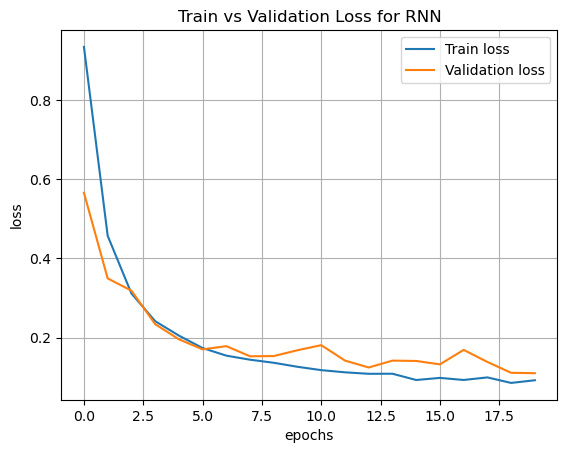

In [7]:
df_loss = pd.DataFrame({
    "Train loss": train_loss_history,
    "Validation loss": val_loss_history
})

plt.plot(df_loss["Train loss"], label="Train loss")
plt.plot(df_loss["Validation loss"], label="Validation loss")

plt.title("Train vs Validation Loss for RNN")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint</u>

In [8]:
model.load_state_dict(torch.load("best_rnn_model.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluate</u>

Batch-accumulated pattern, same as CIFAR10/cat-dog/sentiment: loop over each loader, collect predictions and labels batch by batch, `torch.cat` together, compute metrics once on the full set.

`torch.argmax(y_pred_tensor, dim=1)`: `y_pred_tensor` is `(batch_size, 10)`, 10 raw scores per image. `dim=1` tells argmax which axis to search across for the max: axis 0 is "which image," axis 1 is "which of its 10 class scores." `dim=1` means "for each image, find the index of its highest score," giving one predicted digit per image. `dim=0` would instead compare different images against each other for each class column, not what's wanted here.

`average='weighted'` on precision/recall/F1 since this is multiclass (10 digits), same convention as DateFruit/CIFAR10.

In [9]:
model.eval()

all_train_preds = []
all_train_labels = []
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for x_train_batch, y_train_batch in train_loader:

        y_train_pred_tensor = model(x_train_batch)
        # argmax searches for the index with highest probability
        # dim = 1 tells argmax to look at axis 1
        # axis 0 is "which image in the batch," axis 1 is "which of the 10 class scores."
        # dim=1 means "for each image, look across its 10 scores and give me the index of the highest one"
        predicted_train_classes = torch.argmax(y_train_pred_tensor, dim=1) 

        all_train_preds.append(predicted_train_classes)
        all_train_labels.append(y_train_batch)

    for x_test_batch, y_test_batch in test_loader:

        y_test_pred_tensor = model(x_test_batch)
        predicted_test_classes = torch.argmax(y_test_pred_tensor, dim=1)

        all_test_preds.append(predicted_test_classes)
        all_test_labels.append(y_test_batch)

# stitch every batch's small tensor into one tensor covering the full set
all_train_preds = torch.cat(all_train_preds)
all_train_labels = torch.cat(all_train_labels)
all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)

print("For Training:")
print(f"Accuracy Score : {accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Precision Score : {precision_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print("\n")
print("For Testing:")
print(f"Accuracy Score : {accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Precision Score : {precision_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")

For Training:
Accuracy Score : 0.9829019607843137
Precision Score : 0.9829949476591647
Recall Score : 0.9829019607843137
F1 Score : 0.9829144904954743


For Testing:
Accuracy Score : 0.9731
Precision Score : 0.9732312602873222
Recall Score : 0.9731
F1 Score : 0.9731308534656326
